# SM CEvNS — Standard Model Coherent Elastic Neutrino-Nucleus Scattering

This notebook uses the **NuRecoil** package to compute the SM CEvNS differential
cross section, total cross section, and detector event rate.

Units follow `misc/plans/units_convention.md`:
- Energy: **MeV** (internal)
- Cross section: $\text{cm}^2$
- Flux: $\#\,/\,\text{MeV}\,/\,\text{cm}^2$

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import quad

# NuRecoil 模块
import nurecoil.constants as C
from nurecoil.nucleus import Nucleus, ISOTOPE_TABLE
from nurecoil.cross_section.form_factors import HelmFormFactor
from nurecoil.cross_section.sm_cevns import SMCEvNS
from nurecoil.flux.phenomenological import PhenomenologicalFlux

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 2. Physical Constants

Values from `nurecoil.constants` (PDG 2024). All internal energies are in **MeV**.

In [2]:
print(f"G_F          = {C.G_F:.7e}  MeV⁻²")
print(f"G_F_GeV2     = {C.G_F_GeV2:.7e}  GeV⁻²  (PDG reference)")
print(f"ℏc           = {C.hbar_c:.7f}  MeV·fm")
print(f"sin²θ_W      = {C.sin2_theta_W}")
print(f"u_to_MeV     = {C.u_to_MeV}  MeV")
print(f"cm_per_fm    = {C.cm_per_fm:.1e}")
print(f"keV_per_MeV  = {C.keV_per_MeV:.0f}")

G_F          = 1.1663788e-11  MeV⁻²
G_F_GeV2     = 1.1663788e-05  GeV⁻²  (PDG reference)
ℏc           = 197.3269804  MeV·fm
sin²θ_W      = 0.23122
u_to_MeV     = 931.494  MeV
cm_per_fm    = 1.0e-13
keV_per_MeV  = 1000


## 3. Weak Mixing Angle and Couplings

SM tree-level vector couplings:

$$
g_V^p = \frac{1}{2} - 2\sin^2\!\theta_W, \qquad g_V^n = -\frac{1}{2}
$$

The weak charge including nuclear form factors is:

$$
Q_W\!\left(|\vec{q}|\right) = g_V^n\, N\, F_N\!\left(|\vec{q}|\right)
                             + g_V^p\, Z\, F_Z\!\left(|\vec{q}|\right)
$$

In the $|\vec{q}| \to 0$ (low-momentum-transfer) limit, $F_{N,Z} \to 1$, so:

$$
Q_W \approx g_V^n N + g_V^p Z
= -\frac{N}{2} + \left(\frac{1}{2} - 2\sin^2\!\theta_W\right) Z
$$

In [3]:
s2w   = C.sin2_theta_W
g_V_p = 0.5 - 2.0 * s2w   # proton weak vector coupling
g_V_n = -0.5               # neutron weak vector coupling

# Show Q_W (q→0 limit) for a few nuclei
targets = {
    "Ge76":  Nucleus(Z=32, A=76),
    "Si28":  Nucleus(Z=14, A=28),
    "Xe132": Nucleus(Z=54, A=132),
    "Cs133": Nucleus(Z=55, A=133),
    "Ar40":  Nucleus(Z=18, A=40),
}

print(f"{'Nucleus':<8}  {'Z':>4}  {'N':>4}  {'Q_W(q→0)':>10}")
print("-" * 36)
for name, nuc in targets.items():
    Q_W0 = g_V_n * nuc.N + g_V_p * nuc.Z
    print(f"{name:<8}  {nuc.Z:>4}  {nuc.N:>4}  {Q_W0:>10.3f}")

Nucleus      Z     N    Q_W(q→0)
------------------------------------
Ge76        32    44     -20.798
Si28        14    14      -6.474
Xe132       54    78     -36.972
Cs133       55    78     -36.934
Ar40        18    22     -10.324


## 4. CEvNS Differential Cross Section

$$
\frac{d\sigma}{dE_R} = \frac{G_F^2\, M}{\pi}
\left(1 - \frac{E_R}{E_\nu}
     + \frac{1}{2}\!\left(\frac{E_R}{E_\nu}\right)^{\!2}
     - \frac{M E_R}{2E_\nu^2}\right)
\left|Q_W\!\left(|\vec{q}|\right)\right|^2
$$

Momentum transfer: $|\vec{q}| \approx \sqrt{2M E_R}$ [MeV]. The Helm form factor
modifies $Q_W$ at finite $|\vec{q}|$.

The plot below shows $d\sigma/dE_R$ for $^{76}$Ge at several neutrino energies.

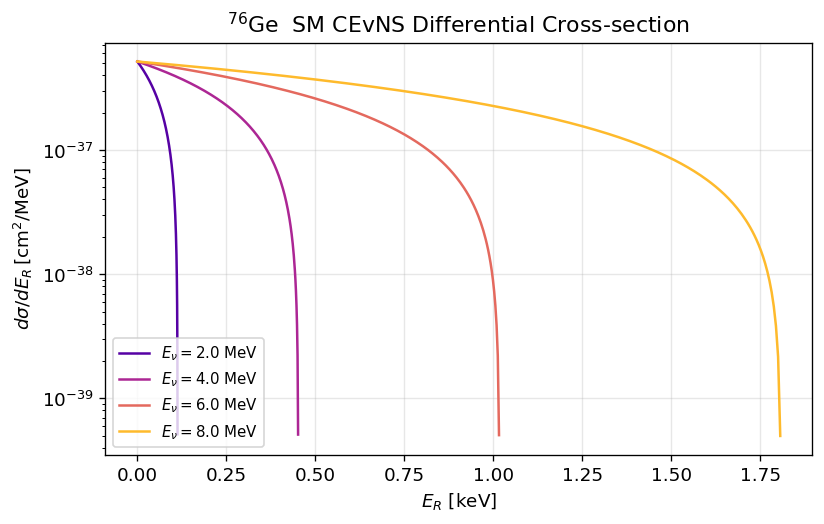

In [5]:
ge76 = Nucleus(Z=32, A=76)
xs_ge76 = SMCEvNS(ge76, HelmFormFactor())

fig, ax = plt.subplots(figsize=(7, 4.5))

E_nu_values = [2.0, 4.0, 6.0, 8.0]   # MeV
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(E_nu_values)))

for E_nu, col in zip(E_nu_values, colors):
    E_R_max = xs_ge76.E_R_max(E_nu)
    E_R = np.linspace(0.0, E_R_max * 0.999, 300)   # MeV
    dsig = xs_ge76(E_nu, E_R)                        # cm² / MeV

    # Plot in keV for readability
    ax.plot(E_R * C.keV_per_MeV, dsig, color=col, label=f"$E_\\nu = {E_nu}$ MeV")

ax.set_xlabel("$E_R$ [keV]")
ax.set_ylabel(r"$d\sigma/dE_R\, {\rm [cm^{2} / MeV]}$")
ax.set_title("$^{76}$Ge  SM CEvNS Differential Cross-section")
ax.set_yscale("log")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Total Cross Section via $E_R$ Integration

$$
\sigma(E_\nu) = \int_0^{E_R^{\max}} \frac{d\sigma}{dE_R}\, dE_R,
\qquad
E_R^{\max} = \frac{2E_\nu^2}{M + 2E_\nu}
$$

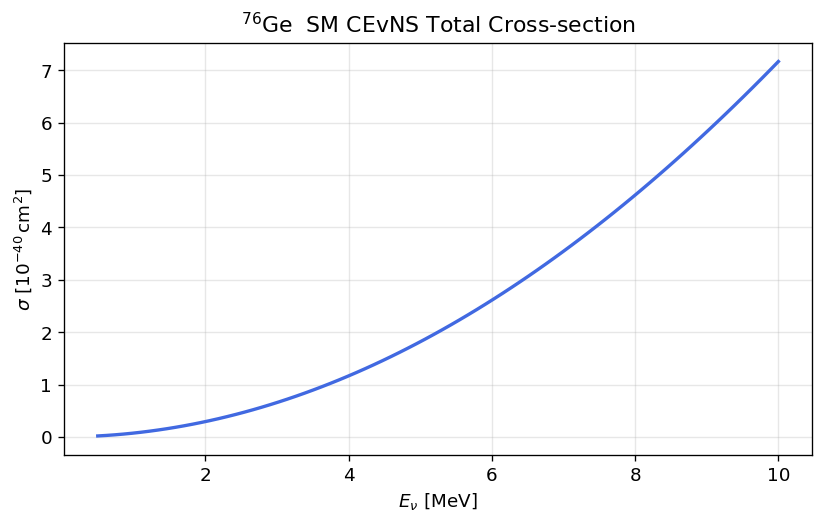

$\sigma(E_\nu=5\,{\rm MeV}) \approx 1.815e-40\, \rm cm^2$


In [7]:
def total_xsec(xs_model, E_nu_arr):
    """Numerically integrate dσ/dE_R from 0 to E_R_max for each E_nu."""
    sigma = np.empty_like(E_nu_arr)
    for i, E_nu in enumerate(E_nu_arr):
        E_R_max = xs_model.E_R_max(float(E_nu))
        val, _ = quad(
            lambda E_R: float(xs_model(float(E_nu), E_R)),
            0.0, E_R_max,
            limit=80,
        )
        sigma[i] = val
    return sigma   # cm²

E_nu_grid = np.linspace(0.5, 10.0, 80)   # MeV
sigma_ge76 = total_xsec(xs_ge76, E_nu_grid)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(E_nu_grid, sigma_ge76 / 1e-40, color="royalblue", lw=2)
ax.set_xlabel("$E_\\nu$ [MeV]")
ax.set_ylabel(r"$\sigma$ [$10^{-40}\,\rm cm^{2}$]")
ax.set_title("$^{76}$Ge  SM CEvNS Total Cross-section")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(fr"$\sigma(E_\nu=5\,{{\rm MeV}}) \approx {np.interp(5.0, E_nu_grid, sigma_ge76):.3e}\, \rm cm^{2}$")

## 6. CEvNS Event Rate for Different Target Nuclei

Convolve the reactor antineutrino flux (Huber–Mueller parametrisation) with the
SM CEvNS cross section; integrate over the full phase space to get the rate per
target atom per second:

$$
R = \int_{E_\nu} \int_{E_R}
    \frac{d\Phi}{dE_\nu}\,
    \frac{d\sigma}{dE_R}\;
    dE_R\, dE_\nu
$$

Parameters: $P = 3\ \text{GW}$, $L = 30\ \text{m}$, $N_T = 1$ (per target atom).

In [8]:
from scipy.integrate import dblquad

flux_model = PhenomenologicalFlux()

P_GW  = 3.0   # GW
L_m   = 30.0  # m

E_nu_min, E_nu_max = 1.8, 8.0   # MeV  (reactor ν̄_e window)

def rate_per_atom(nucleus):
    """Integrated rate [events / atom] (no detector smearing)."""
    xs_model = SMCEvNS(nucleus, HelmFormFactor())

    def integrand(E_R, E_nu):
        phi  = float(flux_model(E_nu, P_GW, L_m))
        dsig = float(xs_model(E_nu, E_R))
        return phi * dsig

    val, _ = dblquad(
        integrand,
        E_nu_min, E_nu_max,
        0.0,
        lambda E_nu: xs_model.E_R_max(E_nu),
        epsrel=1e-3,
    )
    return val   # events / atom / s  (flux already per s via GW conversion)

print("Computing rates (this may take ~30 s) …")
rates = {}
for name, nuc in targets.items():
    rates[name] = rate_per_atom(nuc)
    print(f"  {name:<8}  {rates[name]:.3e} events/atom/s")
print("Done.")

Computing rates (this may take ~30 s) …
  Ge76      1.047e-28 events/atom/s
  Si28      1.015e-29 events/atom/s
  Xe132     3.304e-28 events/atom/s
  Cs133     3.297e-28 events/atom/s
  Ar40      2.581e-29 events/atom/s
Done.


## 7. Visualisation: Differential and Total Cross Sections

Compare the differential cross-section shape for Ge, Si, and Xe at fixed
$E_\nu = 5\ \text{MeV}$, and the total cross section $\sigma(E_\nu)$.

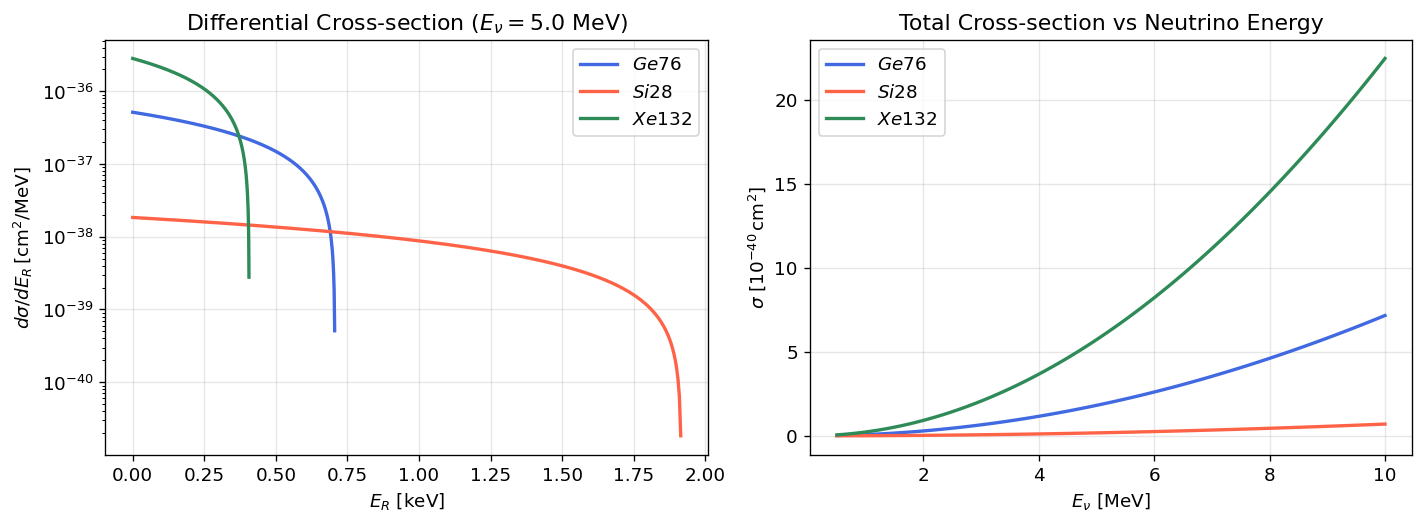

In [10]:
E_nu_plot = 5.0   # MeV

plot_targets = {
    "Ge76":  (Nucleus(Z=32, A=76),  "royalblue"),
    "Si28":  (Nucleus(Z=14, A=28),  "tomato"),
    "Xe132": (Nucleus(Z=54, A=132), "seagreen"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Left: dσ/dE_R ---
ax = axes[0]
for name, (nuc, col) in plot_targets.items():
    xs_m = SMCEvNS(nuc, HelmFormFactor())
    E_R_max = xs_m.E_R_max(E_nu_plot)
    E_R = np.linspace(0.0, E_R_max * 0.999, 400)
    dsig = xs_m(E_nu_plot, E_R)
    ax.plot(E_R * C.keV_per_MeV, dsig, color=col, lw=2, label=f"${name}$")

ax.set_xlabel("$E_R$ [keV]")
ax.set_ylabel(r"$d\sigma/dE_R\, {\rm [cm^{2} / MeV]}$")
ax.set_title(f"Differential Cross-section ($E_\\nu = {E_nu_plot}$ MeV)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: σ(E_nu) ---
ax = axes[1]
for name, (nuc, col) in plot_targets.items():
    xs_m = SMCEvNS(nuc, HelmFormFactor())
    sig  = total_xsec(xs_m, E_nu_grid)
    ax.plot(E_nu_grid, sig / 1e-40, color=col, lw=2, label=f"${name}$")

ax.set_xlabel("$E_\\nu$ [MeV]")
ax.set_ylabel(r"$\sigma$ [$10^{-40}\,\rm cm^{2}$]")
ax.set_title("Total Cross-section vs Neutrino Energy")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Event-Rate Comparison Across Target Nuclei

The CEvNS cross section scales approximately as $N^2$ (coherent neutron contribution).
The plots below visualise the rate for each nucleus and verify the $\sigma \propto Q_W^2$
scaling directly.

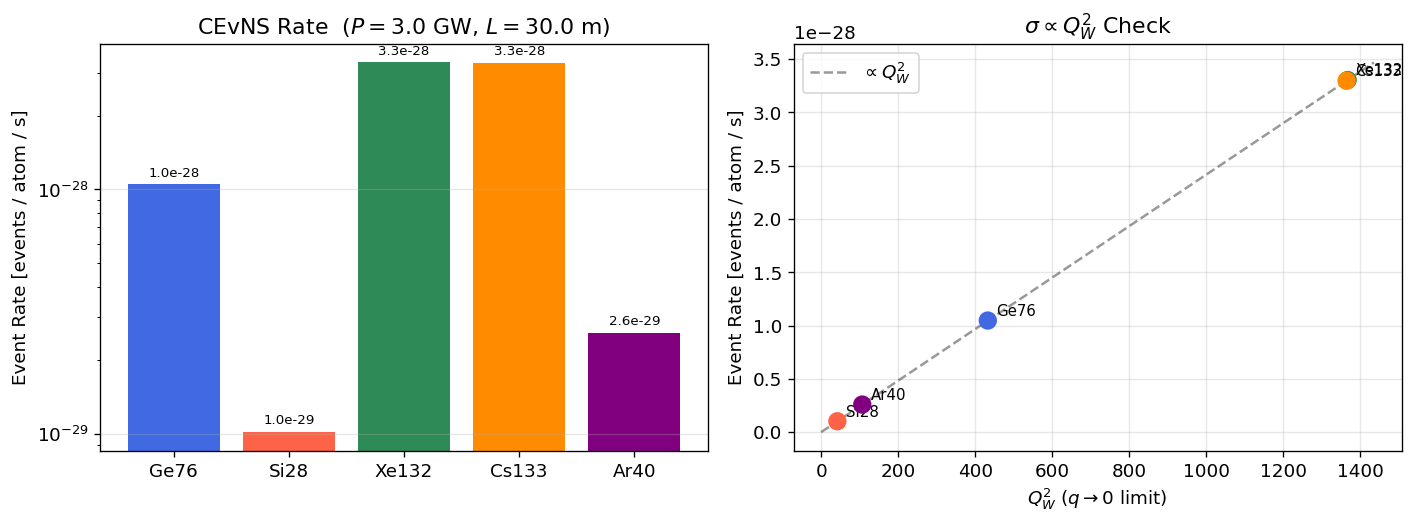

In [12]:
names  = list(rates.keys())
R_vals = np.array([rates[n] for n in names])
N_vals = np.array([targets[n].N for n in names])
Q_vals = np.array([g_V_n * targets[n].N + g_V_p * targets[n].Z for n in names])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bar_colors = ["royalblue", "tomato", "seagreen", "darkorange", "purple"]

# --- Left: event rate bar chart ---
ax = axes[0]
bars = ax.bar(names, R_vals, color=bar_colors)
ax.set_ylabel("Event Rate [events / atom / s]")
ax.set_title(f"CEvNS Rate  ($P={P_GW}$ GW, $L={L_m}$ m)")
ax.set_yscale("log")
ax.bar_label(bars, fmt="%.1e", padding=3, fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

# --- Right: rate vs Q_W^2 (N^2 scaling check) ---
ax = axes[1]
Q2 = Q_vals ** 2
ax.scatter(Q2, R_vals, c=bar_colors, s=100, zorder=5)
for n, x, y in zip(names, Q2, R_vals):
    ax.annotate(n, (x, y), textcoords="offset points", xytext=(5, 3), fontsize=9)

# Fit a proportionality line
slope = np.polyfit(Q2, R_vals, 1)[0]
x_fit = np.linspace(0, Q2.max() * 1.05, 100)
ax.plot(x_fit, slope * x_fit, "k--", alpha=0.4, label=f"$\\propto Q_W^2$")
ax.set_xlabel("$Q_W^2$ ($q\\to 0$ limit)")
ax.set_ylabel("Event Rate [events / atom / s]")
ax.set_title("$\\sigma \\propto Q_W^2$ Check")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()